# Image Classification with MNIST — The "Hello World" of Deep Learning

**Lecture 05 — Deep Learning** · EAFIT


- A clearer separation between **Dataset** and **DataLoader** concepts (including a
  from-scratch custom `Dataset` example).
- Practical **tips** (green boxes) that explain *why*, not just *how*.
- **Early stopping + checkpointing**
- **Training curves** (loss/accuracy) — the plots shown in the slides.
- **Saving/loading the model** for future inference (the open question at the end of the slides).
- A short **error analysis** (confusion matrix + misclassified digits).



## 1. Objectives

By the end of this notebook you will be able to:

- Explain **why** deep learning is a good fit for image classification (vs. rule-based programming).
- Describe the MNIST dataset and how PyTorch/TorchVision expose it.
- Explain the difference between a **`Dataset`** (what the data *is*) and a
  **`DataLoader`** (how the data is *served* to the model), and write a minimal
  custom `Dataset` from scratch.
- Build a fully-connected neural network with `nn.Sequential`.
- Train the network with a proper training loop, **track metrics**, and plot
  learning curves.
- Apply **early stopping** and **checkpointing** to keep the best model.
- Save the trained model and reload it for inference on new data.


## 2. Setup

Install the libraries we need. In Colab/Kaggle these are usually already installed — run this cell once and comment it out afterwards to save time.

In [ ]:
# !pip install torch torchvision torchaudio
# !pip install matplotlib scikit-learn

Now import everything we'll use. Grouping imports by purpose (core PyTorch,
data, visualization) makes the notebook easier to read and is good practice for
any real project.

In [ ]:
import time
import copy

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam

# Data & visualization tools
import torchvision
import torchvision.transforms.v2 as transforms
import torchvision.transforms.functional as F
import matplotlib.pyplot as plt
import numpy as np

# Only needed for the error-analysis section at the end
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

### 2.1 Choosing a device (CPU vs GPU)

PyTorch tensors and models must live on a specific piece of hardware — the
`device`. Training on a GPU (`cuda`) is typically **10-50x faster** than on a
CPU for this kind of workload because GPUs can perform thousands of matrix
multiplications in parallel.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
torch.cuda.is_available()

Using device: cpu


False

## 3. The Problem and the Solution

Recognizing handwritten digits is a simple task for humans, but a challenging problem for a computer. The same digit can be written in many different ways depending on the person, handwriting style, size, position, or stroke thickness.

For example, two images may both represent the digit 7, even though their pixel patterns can look very different.

The goal is therefore to build a model that can learn relevant patterns from examples and correctly classify a new handwritten image into one of 10 possible classes (0–9).

This makes handwritten digit recognition an ideal “Hello World” problem for Deep Learning.

## 4. The MNIST Dataset

MNIST contains **70,000 grayscale images** of handwritten digits (0-9), each
**28×28 pixels**. It's split into:

- **60,000** training images
- **10,000** test images (we'll use them as our *validation* set)

Historically, reaching high accuracy on MNIST was a landmark result. Today
it's considered "the Hello World of Deep Learning" — trivial to solve well,
but a perfect sandbox to learn the full end-to-end workflow.

### 4.1 Why do we need *four* pieces of data?

Think of `(X, y)` pairs as flash cards:

| Variable   | What it is                                   | Used for              |
|------------|-----------------------------------------------|------------------------|
| `x_train`  | Training images                              | The model *studies* these |
| `y_train`  | Correct labels for `x_train`                 | Used to compute the training loss |
| `x_valid`  | Images the model has **never** trained on    | The model is *quizzed* on these |
| `y_valid`  | Correct labels for `x_valid`                 | Used to compute validation accuracy |

If we only checked performance on the training data, we'd have no way to know
whether the model *memorized* the flash cards or *actually learned* the
underlying patterns (this is the core idea behind **overfitting**, which
we'll revisit later).

### 4.2 Loading MNIST with TorchVision

`torchvision.datasets.MNIST` is a ready-made **`Dataset`** class: it knows how
to download, store, and index the MNIST images and labels. It is a subclass
of `torch.utils.data.Dataset`, the same base class we will subclass ourselves
in section 6.

> Note: TorchVision labels the second split as `Split: Test`, but we are
> using it here as our *validation* set (checking performance after each
> training epoch, not as a final, untouched test set).

In [ ]:
train_set = torchvision.datasets.MNIST("./data/", train=True, download=True)
valid_set = torchvision.datasets.MNIST("./data/", train=False, download=True)

print(train_set)
print(valid_set)

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 490kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.48MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.0MB/s]

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data/
    Split: Train
Dataset MNIST
    Number of datapoints: 10000
    Root location: ./data/
    Split: Test


### 4.3 Exploring a single example

In [ ]:
x_0, y_0 = train_set[0]   # __getitem__(0) under the hood
print(type(x_0), type(y_0))
print("label:", y_0)
x_0  # a PIL.Image.Image — nothing is a tensor yet!

<class 'PIL.Image.Image'> <class 'int'>
label: 5


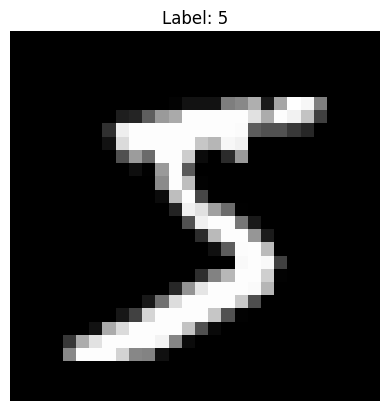

In [ ]:
plt.imshow(x_0, cmap="gray")
plt.title(f"Label: {y_0}")
plt.axis("off")
plt.show()

## 5. `Dataset` vs `DataLoader` — the two concepts you must not confuse

This is one of the most common sources of confusion for people learning
PyTorch, so let's be very explicit:

| Concept | Answers the question | Analogy |
|---|---|---|
| **`Dataset`** | *"What is item number `i`, and how many items are there?"* | A deck of flash cards, in a fixed order, in a box |
| **`DataLoader`** | *"How do I hand out batches of cards to the model, shuffled or not?"* | The teacher who shuffles the deck and hands out 32 cards at a time |

A `Dataset` only needs to implement **three** things:

```python
class MyDataset(Dataset):
    def __init__(self, ...):      # load / point to your data
        ...
    def __len__(self):            # how many samples total?
        ...
    def __getitem__(self, idx):   # return the (x, y) pair at position idx
        ...
```

Anything that implements this contract — a folder of images, a CSV file, a
list of tensors — can be wrapped by a `DataLoader` and fed to a model in
exactly the same way. This is *why* the same `DataLoader` code works for
MNIST, CIFAR-10, or your own custom dataset.

**TIP** — When you inherit from a library `Dataset` (like `MNIST`) you get
`__len__` and `__getitem__` for free. When you have *your own* data (a folder
of photos, a CSV of tabular data...), you write these three methods
yourself — that's exactly what we do next.

### 5.1 Writing a minimal custom `Dataset` from scratch

To make the abstraction concrete, let's build a tiny custom dataset from a
NumPy array — no MNIST magic involved. This is the pattern you'll reuse for
almost any real-world project.

In [ ]:
class TensorDigitsDataset(Dataset):
    """A minimal Dataset wrapping raw arrays.

    Any object that implements __len__ and __getitem__ can be used inside a
    PyTorch DataLoader -- this is the whole contract.
    """

    def __init__(self, images, labels, transform=None):
        self.images = images        # e.g. a NumPy array of shape (N, 28, 28)
        self.labels = labels        # e.g. a NumPy array of shape (N,)
        self.transform = transform  # optional preprocessing (see Section 7)

    def __len__(self):
        # DataLoader calls this to know how many samples exist
        return len(self.images)

    def __getitem__(self, idx):
        # DataLoader calls this (with a random or sequential idx) to fetch one sample
        image = self.images[idx]
        label = int(self.labels[idx])
        if self.transform:
            image = self.transform(image)
        return image, label


# Quick smoke test with 5 fake "images" (just random noise, for illustration only)
fake_images = np.random.randint(0, 256, size=(5, 28, 28), dtype=np.uint8)
fake_labels = np.array([3, 7, 1, 9, 4])

toy_dataset = TensorDigitsDataset(fake_images, fake_labels)
print("Dataset size:", len(toy_dataset))
img, lbl = toy_dataset[2]
print("Item 2 -> image shape:", img.shape, "| label:", lbl)

Dataset size: 5
Item 2 -> image shape: (28, 28) | label: 1


**DISCUSS WITH THE CLASS**: What would you need to change in
`TensorDigitsDataset` if your images lived as `.png` files on disk instead of
in memory? *(Hint: you'd store file paths in `__init__` and call
`PIL.Image.open(path)` inside `__getitem__`, so images are only loaded when
actually needed — this keeps RAM usage low for large datasets.)*

## 6. Tensors

Neural networks operate on **tensors**, not images or Python lists. A tensor
is simply an n-dimensional array:

- 0-D tensor → a scalar
- 1-D tensor → a vector
- 2-D tensor → a matrix
- 3-D+ tensor → e.g. `channels × height × width` for an image, or
  `batch × channels × height × width` for a *batch* of images

Let's convert our PIL image into a tensor using TorchVision's `ToTensor`
transform.

In [ ]:
trans = transforms.Compose([transforms.ToTensor()])
x_0_tensor = trans(x_0)

print("dtype:", x_0_tensor.dtype)
print("min / max:", x_0_tensor.min().item(), "/", x_0_tensor.max().item())
print("shape (C x H x W):", x_0_tensor.size())

dtype: torch.float32
min / max: 0.0 / 1.0
shape (C x H x W): torch.Size([1, 28, 28])


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


`ToTensor` does two things at once:

1. Converts the PIL image into a `torch.FloatTensor`.
2. **Normalizes** pixel values from the integer range `[0, 255]` to the float
   range `[0.0, 1.0]`.

**TIP** — Normalization matters a lot. Neural networks train faster and
more reliably when their inputs are on a small, consistent numeric scale.
Feeding raw `[0, 255]` pixel values (or worse, unnormalized features with very
different scales) can make training slow or unstable.

In [ ]:
# By default tensors live on the CPU
print("device:", x_0_tensor.device)

# Move to GPU (if available) — this is what to(device) does for us safely
x_0_tensor_device = x_0_tensor.to(device)
print("device after .to(device):", x_0_tensor_device.device)

device: cpu
device after .to(device): cpu


**TIP** — Prefer `.to(device)` over `.cuda()`. `.cuda()` crashes if no GPU is available, while `.to(device)` gracefully falls back to CPU because of how we defined `device` above.

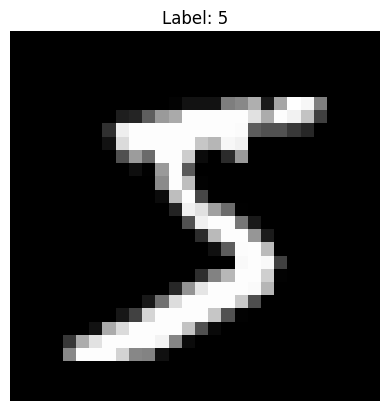

In [ ]:
# Converting back to an image for visualization
image = F.to_pil_image(x_0_tensor)
plt.imshow(image, cmap='gray')
plt.title(f"Label: {y_0}")
plt.axis('off')
plt.show()

## 7. Preparing the Data for Training

### 7.1 Transforms

A `transform` is just a function (or a pipeline of functions, via `Compose`)
applied to every sample when it's loaded. We attach it directly to the
dataset's `.transform` attribute, so every call to `__getitem__` applies it
automatically.

In [ ]:
train_set.transform = trans
valid_set.transform = trans

### 7.2 DataLoaders — batching, shuffling, and more

We already built a `Dataset`. Now let's wrap it with a `DataLoader`, which
handles:

- **Batching**: grouping samples into mini-batches instead of feeding one
  image at a time (too slow) or the whole dataset at once (too much memory,
  and — [research shows](https://arxiv.org/pdf/1804.07612) — usually worse
  generalization).
- **Shuffling**: randomizing sample order every epoch so the model doesn't
  learn spurious patterns tied to data order.
- **Parallel loading**: prefetching the next batch while the GPU is busy with
  the current one (`num_workers`).

| Parameter | Train | Validation | Why |
|---|---|---|---|
| `shuffle` | `True` | `False` | We want to break patterns during training; order doesn't matter for evaluation |
| `batch_size` | 32-128 typical | can be larger | Trade-off between speed, memory, and gradient noise |
| `num_workers` | >0 on real datasets | >0 | Loads data in background processes, in parallel with GPU compute |
| `pin_memory` | `True` if using GPU | `True` | Speeds up the CPU→GPU transfer |
| `drop_last` | optional | `False` | Drop an incomplete final batch if batch-norm layers need a fixed batch size |


In [ ]:
batch_size = 32

train_loader = DataLoader(
    train_set,
    batch_size=batch_size,
    shuffle=True,          # shuffle every epoch (only needed for training)
    num_workers=0,         # increase (e.g. 2-4) on a real machine with a real dataset
    pin_memory=torch.cuda.is_available(),
)
valid_loader = DataLoader(
    valid_set,
    batch_size=batch_size,
    shuffle=False,         # no need to shuffle for evaluation
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

# Peek at one batch to build intuition about shapes
xb, yb = next(iter(train_loader))
print("batch of images shape:", xb.shape)   # (batch_size, 1, 28, 28)
print("batch of labels shape:", yb.shape)   # (batch_size,)

batch of images shape: torch.Size([32, 1, 28, 28])
batch of labels shape: torch.Size([32])


**DISCUSS WITH THE CLASS**: With `batch_size=32` and 60,000 training
images, how many batches (iterations) make up **one epoch**? *(Answer:
`60000 / 32 ≈ 1875` batches per epoch.)*

**TIP — choosing `batch_size`**: small batches (4-16) give noisier but
sometimes more generalizable updates and use little memory; large batches
(256+) are faster per epoch and more stable but need more GPU memory and can
generalize slightly worse. **32 or 64 is a safe default** for most problems —
tune it later as an experiment, not a first guess.

## 8. Building the Model

We'll build a simple **fully-connected (dense) network** using PyTorch's
[`nn.Sequential`](https://pytorch.org/docs/stable/generated/torch.nn.Sequential.html)
API — the simplest way to stack layers when data flows straight through, one
layer after another, with no branching.

Our network needs 4 pieces:

1. **`Flatten`** — turns the `(1, 28, 28)` image into a `(784,)` vector.
2. **Input layer** — a `Linear` layer connecting 784 inputs to N neurons.
3. **Hidden layer** — another `Linear` layer that lets the network combine
   features in more complex, non-linear ways.
4. **Output layer** — 10 neurons, one per digit class (0-9).


### 8.1 The Input Layer

[`nn.Linear(in_features, out_features)`](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html)
creates a *densely connected* layer: every input feature is connected to
every output neuron, each connection has a learnable weight, and each
neuron has a learnable bias.

We must tell it how many input features to expect — the flattened image
size, `1 * 28 * 28 = 784`.

In [ ]:
input_size = 1 * 28 * 28
print(input_size)

784


Choosing the number of neurons (here `512`) is part science, part
experimentation — bigger isn't always better (see the parameter-count
discussion below). We also add a **`ReLU`** activation:

$$\text{ReLU}(z) = \max(0, z)$$

Without a non-linear activation between layers, stacking multiple `Linear`
layers is mathematically equivalent to a single `Linear` layer — the network
would never be able to learn non-linear patterns (like "5 vs 3" written in
messy handwriting).

In [ ]:
layers = [
    nn.Flatten(),
    nn.Linear(input_size, 512),  # Input layer
    nn.ReLU(),                   # Non-linear activation
]
layers

[Flatten(start_dim=1, end_dim=-1),
 Linear(in_features=784, out_features=512, bias=True),
 ReLU()]

### 8.3 The Hidden Layer

A hidden layer's input size must match the *previous* layer's output
size (512 neurons in, in this case). Adding depth (more layers) lets the
network build increasingly abstract representations of the input — we'll
dig into *why* this helps in the next lecture.

In [ ]:
layers = [
    nn.Flatten(),
    nn.Linear(input_size, 512),
    nn.ReLU(),
    nn.Linear(512, 512),   # Hidden layer
    nn.ReLU(),
]
layers

[Flatten(start_dim=1, end_dim=-1),
 Linear(in_features=784, out_features=512, bias=True),
 ReLU(),
 Linear(in_features=512, out_features=512, bias=True),
 ReLU()]

### 8.4 The Output Layer

10 neurons — one per digit class. **No activation function here**: we leave
the raw scores (called *logits*) untouched and let the loss function
(`CrossEntropyLoss`, Section 9.1) apply `softmax` internally. This is a very
common PyTorch gotcha: don't add your own `Softmax` before `CrossEntropyLoss`,
or you'll apply it twice by accident.

In [ ]:
n_classes = 10

layers = [
    nn.Flatten(),
    nn.Linear(input_size, 512),  # Input
    nn.ReLU(),
    nn.Linear(512, 512),         # Hidden
    nn.ReLU(),
    nn.Linear(512, n_classes),   # Output (raw logits, no activation)
]
layers

[Flatten(start_dim=1, end_dim=-1),
 Linear(in_features=784, out_features=512, bias=True),
 ReLU(),
 Linear(in_features=512, out_features=512, bias=True),
 ReLU(),
 Linear(in_features=512, out_features=10, bias=True)]

### 8.5 Assembling the model with `Sequential`

`nn.Sequential` expects its layers as **separate positional arguments**, not
a single list — so we "unpack" our list with `*layers`.

In [ ]:
model = nn.Sequential(*layers)
model

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=512, bias=True)
  (2): ReLU()
  (3): Linear(in_features=512, out_features=512, bias=True)
  (4): ReLU()
  (5): Linear(in_features=512, out_features=10, bias=True)
)

### 8.6 How many parameters does this model have?

Every weight and bias the optimizer has to learn counts as one parameter.
More parameters roughly mean:

- More representational capacity (can fit more complex patterns) — but also
  more risk of **overfitting** if you don't have enough data.
- More memory required (each `float32` parameter costs 4 bytes).


In [ ]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable_params:,}")

memory_mb = (total_params * 4) / (1024 ** 2)
print(f"Memory (weights only, float32): {memory_mb:.2f} MB")

By hand, `parameters = (in_features * out_features) + biases`:

- Layer 1 `Linear(784, 512)` → `784*512 + 512 = 401,920`
- Layer 2 `Linear(512, 512)` → `512*512 + 512 = 262,656`
- Layer 3 `Linear(512, 10)`  → `512*10 + 10 = 5,130`
- **Total ≈ 669,706 parameters ≈ 2.7 MB**

For comparison, GPT-3 has **175 billion** parameters (~650 GB in float32) —
this is exactly why huge models need huge, specialized hardware, and why we
start learning on something as small as MNIST.

**TIP** — Rule of thumb: too few parameters → **underfitting** (the model
can't even fit the training data well). Too many parameters relative to your
data → **overfitting** (the model memorizes training examples instead of
learning general patterns).

### 8.7 Moving the model to the device

In [ ]:
model.to(device)
print("Model is on:", next(model.parameters()).device)

Model is on: cpu


### 8.8 (Optional) `torch.compile` for speed

[PyTorch 2.0](https://pytorch.org/get-started/pytorch-2.0/) introduced
`torch.compile`, which can speed up training with a single line of code by
compiling your model into optimized kernels.

**Pros**: usually faster (especially on modern GPUs), one line, no other code
changes needed.
**Cons**: the very first call pays a "warm-up" compilation cost, and for tiny
models like ours the benefit may be negligible or even negative.

In [ ]:
model = torch.compile(model)

## 9. Training the Model

"Training" (or "fitting") a model means iteratively updating its parameters
so that its predictions get closer to the correct labels.

### 9.1 Loss function

Just like a teacher grades an exam, the model needs a numeric grade for how
wrong its predictions are: the **loss function**. For multi-class
classification we use
[`CrossEntropyLoss`](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html):

$$CE = -\sum_{i=1}^{N} y_i \log(p_i)$$

Since `y` is one-hot encoded (all zeros except a 1 at the correct class), all
terms cancel except the one for the true class — so `CrossEntropyLoss`
reduces to "how confident was the model in the *correct* answer?" If the
model assigned probability `0.20` to the true class, the loss for that
sample is `-log(0.20) ≈ 1.61`. A perfect prediction (`p=1.0`) gives a loss of
`0`.

In [ ]:
loss_function = nn.CrossEntropyLoss()

### 9.2 Optimizer

If the loss function is the grade, the **optimizer** is *how the model
studies* based on that grade — it decides how to nudge every parameter to
reduce the loss (gradient descent, under the hood).
[`Adam`](https://pytorch.org/docs/stable/generated/torch.optim.Adam.html) is
a strong general-purpose default because it **adapts the learning rate per
parameter automatically**, which tends to converge faster and more reliably
than plain SGD, especially for beginners.

In [ ]:
optimizer = Adam(model.parameters())

**TIP — other optimizers you'll see in the wild**: `SGD` (+momentum),
`RMSProp`, `AdaGrad`, `AdaDelta`. Empirically (see the classic comparison
plot in the slides), `Adam` tends to converge fastest and most smoothly for a
wide range of problems — which is why it's the default choice unless you
have a specific reason to use something else.

### 9.3 Accuracy metric

Loss values (e.g. `142.37`) are hard for humans to interpret. **Accuracy** —
the fraction of correctly classified samples — is far more intuitive, so
we'll track both.

In [ ]:
train_N = len(train_loader.dataset)
valid_N = len(valid_loader.dataset)

def get_batch_accuracy(output, y, N):
    """Fraction of correct predictions in this batch, scaled by dataset size N.

    Because we call this once per batch and sum the results, by the time we've
    gone through every batch in an epoch the sum equals the overall accuracy.
    """
    pred = output.argmax(dim=1, keepdim=True)          # index of highest-scoring class
    correct = pred.eq(y.view_as(pred)).sum().item()     # count matches in this batch
    return correct / N

### 9.4 The training loop, step by step

Every training step follows the same 5-step recipe — memorize this pattern,
you'll type it in almost every PyTorch project:

1. **Forward pass**: `output = model(x)` — compute predictions.
2. **Zero the gradients**: `optimizer.zero_grad()` — PyTorch accumulates
   gradients by default, so we must clear old ones before each step.
3. **Compute the loss**: `loss_function(output, y)`.
4. **Backward pass**: `loss.backward()` — PyTorch automatically computes the
   gradient of the loss with respect to every parameter (autograd).
5. **Update parameters**: `optimizer.step()` — the optimizer nudges every
   parameter using its gradient.

`model.train()` switches on training-specific behavior (e.g. dropout,
batch-norm statistics) — always call it before a training epoch.

In [ ]:
def train_one_epoch():
    total_loss = 0
    total_accuracy = 0

    model.train()  # enable training-mode behavior (dropout, batchnorm, etc.)
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        output = model(x)                          # 1. forward pass
        optimizer.zero_grad()                       # 2. clear old gradients
        batch_loss = loss_function(output, y)        # 3. compute loss
        batch_loss.backward()                        # 4. backpropagate
        optimizer.step()                             # 5. update parameters

        total_loss += batch_loss.item()
        total_accuracy += get_batch_accuracy(output, y, train_N)

    print(f"Train - Loss: {total_loss:.4f} Accuracy: {total_accuracy:.4f}")
    return total_loss, total_accuracy

### 9.5 The validation loop

Validation is almost identical, with two key differences:

- `model.eval()` disables training-only behavior.
- `with torch.no_grad():` disables gradient tracking — we're not learning
  here, only measuring, so this saves memory and computation.
- We never call `.backward()` or `optimizer.step()` — the model does **not**
  learn from validation data.

In [ ]:
def validate_one_epoch():
    total_loss = 0
    total_accuracy = 0

    model.eval()
    with torch.no_grad():
        for x, y in valid_loader:
            x, y = x.to(device), y.to(device)
            output = model(x)

            total_loss += loss_function(output, y).item()
            total_accuracy += get_batch_accuracy(output, y, valid_N)

    print(f"Valid - Loss: {total_loss:.4f} Accuracy: {total_accuracy:.4f}")
    return total_loss, total_accuracy

## 10. Early Stopping + Checkpointing

The slides make an important point that the original notebook never actually
implements:

| Technique | What it does | What it guarantees |
|---|---|---|
| **Checkpointing** | Periodically saves the model's weights | You can always recover the model from any saved epoch |
| **Early stopping** | Stops training when validation stops improving | Saves time and avoids over-training (excessive overfitting) |

Together, they guarantee you end up with **the best model seen during
training** — not just whatever the last epoch happened to produce (which,
due to overfitting, is often *worse*).

In [ ]:
class EarlyStopping:
    """Stops training when the monitored value (validation loss) stops improving,
    and keeps a copy of the best model weights seen so far.
    """

    def __init__(self, patience=3, min_delta=0.0):
        self.patience = patience        # how many epochs to wait for improvement
        self.min_delta = min_delta      # minimum change to count as an improvement
        self.best_loss = float("inf")
        self.counter = 0
        self.best_state_dict = None
        self.should_stop = False

    def step(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            # improvement! reset patience and checkpoint the model
            self.best_loss = val_loss
            self.counter = 0
            self.best_state_dict = copy.deepcopy(model.state_dict())
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True

## 11. The Training Loop

An **epoch** is one full pass through the entire training dataset. We
alternate `train_one_epoch()` and `validate_one_epoch()`, track the history
for plotting, and let `EarlyStopping` decide if we should stop early.

In [ ]:
epochs = 15

history = {
    "train_loss": [], "train_acc": [],
    "valid_loss": [], "valid_acc": [],
}

early_stopping = EarlyStopping(patience=4, min_delta=0.0)

for epoch in range(epochs):
    print(f"Epoch: {epoch}")
    tr_loss, tr_acc = train_one_epoch()
    va_loss, va_acc = validate_one_epoch()

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["valid_loss"].append(va_loss)
    history["valid_acc"].append(va_acc)

    early_stopping.step(va_loss, model)
    if early_stopping.should_stop:
        print(f"Early stopping triggered after epoch {epoch} "
              f"(no improvement for {early_stopping.patience} epochs).")
        break

# Always restore the BEST weights seen during training, not necessarily the last ones
if early_stopping.best_state_dict is not None:
    model.load_state_dict(early_stopping.best_state_dict)
    print(f"Restored best model (validation loss = {early_stopping.best_loss:.4f}).")

Epoch: 0
Train - Loss: 373.4420 Accuracy: 0.9394
Valid - Loss: 32.6025 Accuracy: 0.9664
Epoch: 1
Train - Loss: 160.1156 Accuracy: 0.9735
Valid - Loss: 27.6656 Accuracy: 0.9729
Epoch: 2
Train - Loss: 111.0243 Accuracy: 0.9816
Valid - Loss: 22.9365 Accuracy: 0.9777
Epoch: 3
Train - Loss: 83.0794 Accuracy: 0.9860
Valid - Loss: 24.1464 Accuracy: 0.9785
Epoch: 4
Train - Loss: 67.2245 Accuracy: 0.9888
Valid - Loss: 30.4662 Accuracy: 0.9752
Epoch: 5
Train - Loss: 53.1826 Accuracy: 0.9908
Valid - Loss: 21.8572 Accuracy: 0.9816
Epoch: 6
Train - Loss: 49.8736 Accuracy: 0.9916
Valid - Loss: 23.8648 Accuracy: 0.9822
Epoch: 7
Train - Loss: 41.9180 Accuracy: 0.9926
Valid - Loss: 26.2729 Accuracy: 0.9820
Epoch: 8
Train - Loss: 36.4449 Accuracy: 0.9940
Valid - Loss: 28.5248 Accuracy: 0.9806
Epoch: 9
Train - Loss: 35.7901 Accuracy: 0.9940
Valid - Loss: 29.1322 Accuracy: 0.9815
Early stopping triggered after epoch 9 (no improvement for 4 epochs).
Restored best model (validation loss = 21.8572).


### 11.1 Plotting the learning curves

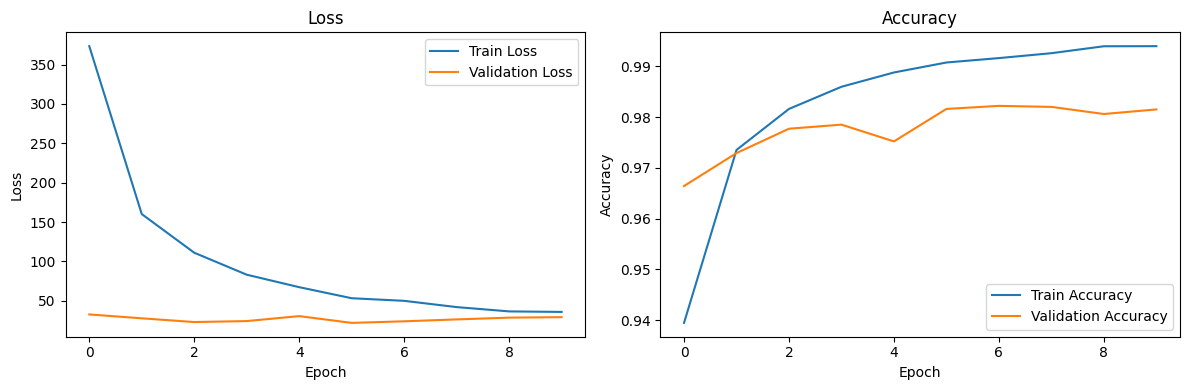

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="Train Loss")
axes[0].plot(history["valid_loss"], label="Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].set_title("Loss")

axes[1].plot(history["train_acc"], label="Train Accuracy")
axes[1].plot(history["valid_acc"], label="Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].set_title("Accuracy")

plt.tight_layout()
plt.show()

**DISCUSS WITH THE CLASS**: If `train_loss` keeps dropping but
`valid_loss` starts climbing back up, what does that tell us? *(Answer: the
model is overfitting — memorizing the training set instead of generalizing.
This is exactly the pattern early stopping protects us from.)*

## 12. Inference: Using the Trained Model

Let's test the model on the very first training example we inspected in
Section 4.3.

In [ ]:
model.eval()
with torch.no_grad():
    prediction = model(x_0_tensor.to(device))

print("raw logits:", prediction)
print("probabilities:", torch.softmax(prediction, dim=1))
print("predicted class:", prediction.argmax(dim=1, keepdim=True).item())
print("true label:", y_0)

raw logits: tensor([[-38.7170, -17.0237, -32.3016,   8.0877, -33.5319,  23.6994, -19.3416,
         -22.8529,  -9.6949,  -4.8472]])
probabilities: tensor([[7.8140e-28, 2.0613e-18, 4.7758e-25, 1.6592e-07, 1.3955e-25, 1.0000e+00,
         2.0300e-19, 6.0613e-21, 3.1406e-15, 4.0026e-13]])
predicted class: 5
true label: 5


The `argmax` finds the index of the highest-scoring output neuron — that
index *is* the predicted digit, because we deliberately used 10 output
neurons ordered 0-9.

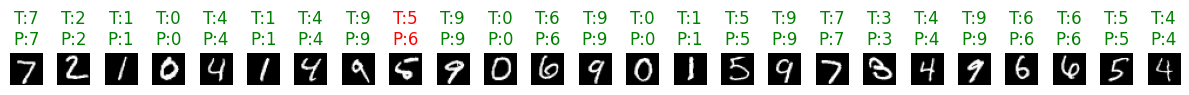

In [ ]:
def show_predictions(model, valid_loader, device, n=25):
    """Show n images from a validation batch with their true (T) and predicted (P) labels."""
    model.eval()

    x, y = next(iter(valid_loader))
    x, y = x.to(device), y.to(device)

    with torch.no_grad():
        logits = model(x)
        preds = logits.argmax(dim=1)

    x, y, preds = x[:n].cpu(), y[:n].cpu(), preds[:n].cpu()

    plt.figure(figsize=(12, 3))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        plt.imshow(x[i].squeeze(), cmap="gray")
        plt.axis("off")
        color = "green" if preds[i] == y[i] else "red"
        plt.title(f"T:{y[i].item()}\nP:{preds[i].item()}", color=color)
    plt.tight_layout()
    plt.show()

show_predictions(model, valid_loader, device, n=25)

💡 **TIP** — Color-coding correct (green) vs. incorrect (red) predictions makes error patterns jump out visually — much faster than reading numbers.

## 13. Error Analysis: Confusion Matrix

Accuracy alone hides *which* classes get confused with which. A confusion
matrix shows exactly that — e.g., does the model confuse 4s with 9s, or 3s
with 8s?

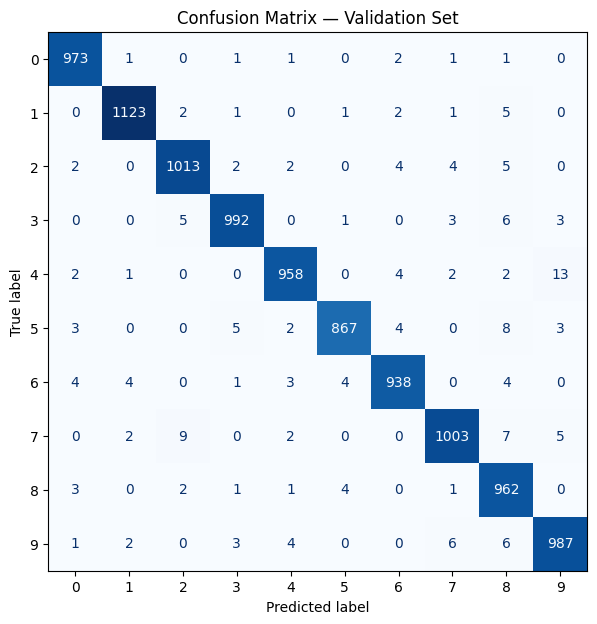

In [ ]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for x, y in valid_loader:
        x = x.to(device)
        logits = model(x)
        preds = logits.argmax(dim=1).cpu()
        all_preds.append(preds)
        all_labels.append(y)

all_preds = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))
fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix — Validation Set")
plt.show()

**DISCUSS WITH THE CLASS**: Look at the off-diagonal cells with the highest counts. Do they make visual sense (e.g., 4↔9, 3↔5, 7↔1)? Why might these particular digits be confused by a fully-connected network?

## 14. Saving and Loading the Model

This answers the open question from the slides: *"¿Cómo guardar el modelo e
implementarlo para futuras predicciones?"*

The recommended way to save a PyTorch model is to save its **`state_dict`**
(a Python dictionary of all learnable parameters) rather than the whole
object — this is more portable across PyTorch versions and code changes.

In [ ]:
torch.save(model.state_dict(), "mnist_model.pt")
print("Model saved to mnist_model.pt")

To reuse the model later (in another script, another day, or in
production), you need:

1. The **same model architecture** (rebuild the class/`Sequential` definition).
2. The saved **`state_dict`** file.

```python
# --- in a NEW session / script ---
loaded_model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 512), nn.ReLU(),
    nn.Linear(512, 512), nn.ReLU(),
    nn.Linear(512, 10),
)
loaded_model.load_state_dict(torch.load("mnist_model.pt", map_location=device))
loaded_model.to(device)
loaded_model.eval()  # always set eval mode before inference!
```

💡 **TIP** — Forgetting `model.eval()` before inference is one of the most
common PyTorch bugs: if your architecture has dropout or batch-norm layers,
skipping `eval()` leaves them in training mode and predictions become
random/unstable.

## 15. Summary & Key Takeaways

- We solved image classification with a fully-connected network reaching
  ~98% validation accuracy — without hand-writing a single classification
  rule.
- **`Dataset`** defines *what* the data is (`__len__`, `__getitem__`);
  **`DataLoader`** defines *how* it's served (batching, shuffling, workers).
- Every training step follows the same 5-step recipe: forward → zero grad →
  loss → backward → optimizer step.
- **Early stopping + checkpointing** protect you from overfitting and
  guarantee you keep the best model, not just the last one.
- Always save/reload models via `state_dict`, and never forget `model.eval()`
  before inference.

### Where to go from here
- Try changing `batch_size`, the number of neurons, or the optimizer, and
  observe the effect on the training curves.
- Next lecture: why do *hidden layers* and *depth* help, and how do
  **Convolutional Neural Networks** exploit the 2-D structure of images that
  a fully-connected network completely ignores (Flatten destroys spatial
  information!).


## 16. (Optional) Clear GPU memory

Run this if you plan to keep working in the same Colab/Jupyter session and
want to free up GPU memory before starting a new notebook.

In [ ]:
# import IPython
# app = IPython.Application.instance()
# app.kernel.do_shutdown(True)